# Week 4: Training Dynamics and Failure Modes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rrfhwn/neural-architectures-and-representation-learning-course/blob/main/weeks/04/Week_04_Training_Dynamics_Failure_Modes.ipynb)

**Course:** Neural Architectures and Representation Learning (Master level)


## Learning goals

- **Recap** the update rule $w \leftarrow w - \eta \, \nabla L$ and see how step size affects convergence.
- Recognize **stable vs unstable** training from loss curves (learning rate too small, good, or too large).
- Understand why **initialization scale** matters (too small → little movement; too large → instability).
- Implement **momentum** as a first fix for noisy or oscillating updates.
- Read **train vs validation** curves and build intuition for **overfitting** (train improves, validation worsens).
- **Diagnose** training: change one knob → re-run → interpret the plot.


---

## Environment

**Dependencies:** `numpy`, `matplotlib` only (no PyTorch in this notebook).

### Local (uv)

From the repo root:

```bash
uv sync
uv run jupyter notebook weeks/04/Week_04_Training_Dynamics_Failure_Modes.ipynb
```

### Colab

1. Open the notebook via the badge above.
2. Runtime → Run all. NumPy and Matplotlib are pre-installed.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.rc('axes', grid=True)
%matplotlib inline


---

## 1. Fast recap (Week 3 in one line)

In **gradient descent**, we nudge each parameter opposite to its gradient:

$$w \leftarrow w - \eta \, \frac{\partial L}{\partial w}$$

Here $\eta$ is the **learning rate** (step size).

**Intuition**

- **Too small $\eta$:** tiny steps → loss decreases **slowly** (many epochs needed).
- **Too large $\eta$:** steps can **overshoot** the minimum → loss may **oscillate** or **blow up** (divergence).

### Mini task

In the cell below, the model is a single weight $w$ minimizing $(w - 3)^2$. **Change `learning_rate`** and re-run. What happens with `0.01` vs `0.3` vs `0.9` vs `1.5`?


Final w = 3.0000 (target 3.0), final loss = 0.000000


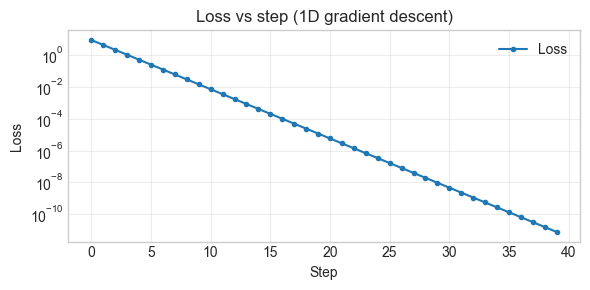

In [2]:
# 1D toy: minimum at w* = 3
w = 0.0
learning_rate = 0.15  # TODO: try e.g. 0.01, 0.3, 0.9, 1.5

losses = []
for step in range(40):
    loss = (w - 3.0) ** 2
    losses.append(loss)
    grad = 2.0 * (w - 3.0)
    w = w - learning_rate * grad

print(f"Final w = {w:.4f} (target 3.0), final loss = {losses[-1]:.6f}")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
loss_plot = np.maximum(losses, 1e-20)
ax.plot(loss_plot, "o-", markersize=3, label="Loss")
ax.set_yscale("log")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Loss vs step (1D gradient descent)")
ax.grid(True, which="both", alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()


---

## Shared setup: tiny MLP in NumPy

The rest of this notebook uses the **same** 2-layer network as in Week 3: input dimension 2, hidden 4, output 1, ReLU, MSE loss. One `forward` / `backward` pair so we can focus on **training behaviour**.

**Mental model for one training step:** forward → loss → backward → update (same as Week 3).


In [3]:
def relu(z):
    return np.maximum(0, z)


def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    return Z2, A1, Z1


def backward(X, A1, Z1, W2, y_pred, y_true):
    n = X.shape[0]
    dL_dy = 2 * (y_pred - y_true) / n
    dL_dz2 = dL_dy
    dL_dW2 = A1.T @ dL_dz2
    dL_db2 = np.sum(dL_dz2, axis=0)
    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * (Z1 > 0)
    dL_dW1 = X.T @ dL_dz1
    dL_db1 = np.sum(dL_dz1, axis=0)
    return dL_dW1, dL_db1, dL_dW2, dL_db2


# Toy regression data (4 samples) — same spirit as Week 3
X_toy = np.array([[1.0, 0.5], [0.5, 1.0], [0.3, 0.8], [0.8, 0.3]], dtype=np.float64)
y_toy = np.array([[2.0], [1.5], [1.2], [1.8]], dtype=np.float64)


def train_sgd(X, y, learning_rate=0.1, init_scale=0.5, n_epochs=120, seed=42):
    # Plain SGD; returns training MSE per epoch
    np.random.seed(seed)
    n_in, n_hid = X.shape[1], 4
    W1 = np.random.randn(n_in, n_hid) * init_scale
    b1 = np.zeros(n_hid)
    W2 = np.random.randn(n_hid, 1) * init_scale
    b2 = np.zeros(1)
    losses = []
    for _ in range(n_epochs):
        y_pred, A1, Z1 = forward(X, W1, b1, W2, b2)
        loss = np.mean((y_pred - y) ** 2)
        losses.append(loss)
        dW1, db1, dW2, db2 = backward(X, A1, Z1, W2, y_pred, y)
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
    return losses


---

## 2. Learning rate behaviour

**Goal:** Same model and data; only the learning rate changes. **Stable** training: loss decreases smoothly. **Unstable** training: loss spikes, oscillates, or explodes.

### Demo: small vs moderate vs large learning rate

**Prediction question (before you run):** which curve will barely move, which will look smooth, which might diverge?


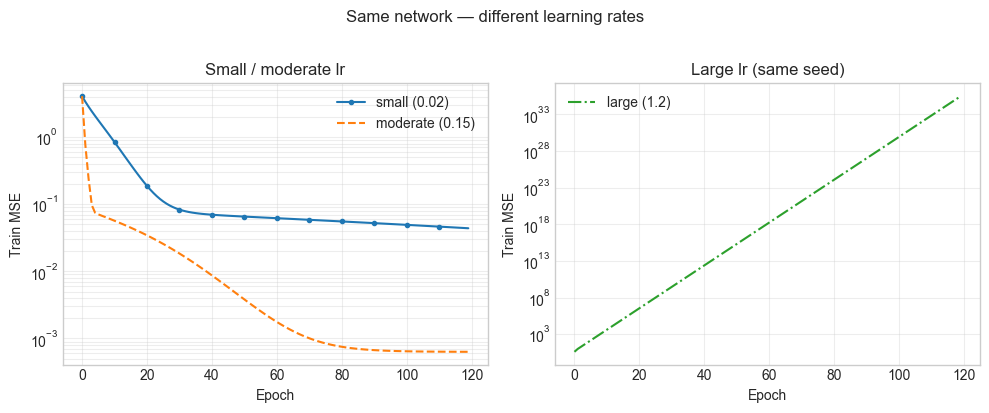

In [4]:
lrs_stable = [0.02, 0.15]
labels_stable = ["small (0.02)", "moderate (0.15)"]
lr_large = 1.2
label_large = "large (1.2)"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
styles = [("-", "o", 10), ("--", None, None)]
for (lr, lab, (ls, mk, me)) in zip(lrs_stable, labels_stable, styles):
    losses = train_sgd(X_toy, y_toy, learning_rate=lr, n_epochs=120, seed=42)
    lp = np.maximum(losses, 1e-20)
    if mk:
        ax1.plot(lp, linestyle=ls, marker=mk, markevery=me, markersize=3, label=lab)
    else:
        ax1.plot(lp, linestyle=ls, label=lab)
ax1.set_yscale("log")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train MSE")
ax1.set_title("Small / moderate lr")
ax1.grid(True, which="both", alpha=0.35)
ax1.legend()

losses_big = train_sgd(X_toy, y_toy, learning_rate=lr_large, n_epochs=120, seed=42)
ax2.plot(np.maximum(losses_big, 1e-20), linestyle="-.", color="C2", label=label_large)
ax2.set_yscale("log")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Train MSE")
ax2.set_title("Large lr (same seed)")
ax2.grid(True, which="both", alpha=0.35)
ax2.legend()

plt.suptitle("Same network — different learning rates", y=1.02)
plt.tight_layout()
plt.show()


**How to read this**

- **Too small:** loss drops slowly — you may need many more epochs.
- **Moderate:** loss falls steadily for this problem.
- **Too large:** updates overshoot; loss can jump (instability).

### Optional intuition: 1D loss landscape

Quadratic $L(w)=(w-2)^2$ with minimum at $w=2$. Large steps can **overshoot** the valley.


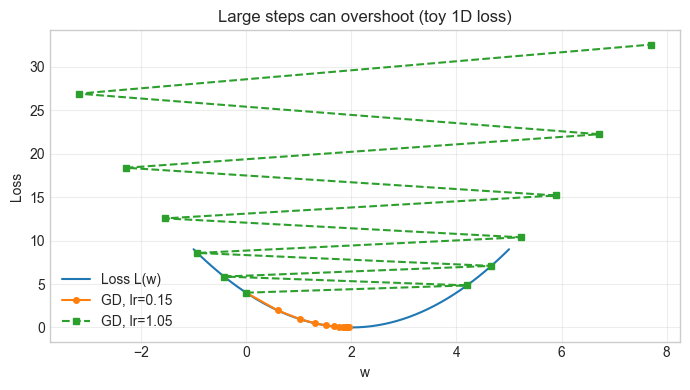

In [5]:
w_grid = np.linspace(-1, 5, 200)
L = (w_grid - 2.0) ** 2

w = 0.0
path_small = []
for _ in range(12):
    path_small.append(w)
    w = w - 0.15 * (2 * (w - 2.0))
w = 0.0
path_large = []
for _ in range(12):
    path_large.append(w)
    w = w - 1.05 * (2 * (w - 2.0))

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(w_grid, L, label="Loss L(w)", linestyle="-")
ax.plot(path_small, [(p - 2) ** 2 for p in path_small], "o-", label="GD, lr=0.15", markersize=4)
ax.plot(path_large, [(p - 2) ** 2 for p in path_large], "s--", label="GD, lr=1.05", markersize=4)
ax.set_xlabel("w")
ax.set_ylabel("Loss")
ax.set_title("Large steps can overshoot (toy 1D loss)")
ax.grid(True, alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()


---

## 3. Initialization

**Goal:** Starting weights set where optimization begins. **Too small** → tiny activations/gradients → slow or stuck. **Too large** → instability (loss spikes).

We vary **`init_scale`** in `randn * init_scale` with fixed learning rate.

### Demo: tiny vs reasonable vs large init


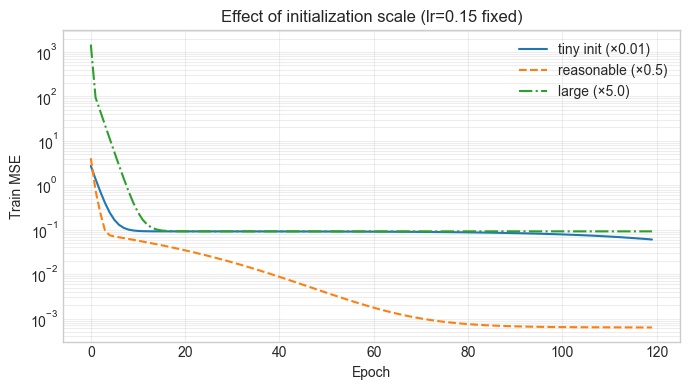

In [6]:
scales = [0.01, 0.5, 5.0]
scale_labels = ["tiny init (×0.01)", "reasonable (×0.5)", "large (×5.0)"]
linestyles = ["-", "--", "-."]

plt.figure(figsize=(7, 4))
for s, lab, ls in zip(scales, scale_labels, linestyles):
    losses = train_sgd(X_toy, y_toy, learning_rate=0.15, init_scale=s, n_epochs=120, seed=42)
    plt.plot(np.maximum(losses, 1e-20), linestyle=ls, label=lab)

plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.yscale("log")
plt.title("Effect of initialization scale (lr=0.15 fixed)")
plt.grid(True, which="both", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


**Plain-language summary**

- **Too small:** often slow progress at the start.
- **Reasonable:** smooth decrease.
- **Too large:** loss may jump — layers amplify large inputs.

This is intuition for a tiny MLP; deeper nets need careful init (later weeks).


---

## 4. Coding block 1 — learning rate sweep (≈40 min)

**Goal:** Change **one thing** (learning rate), re-run, compare curves.

**Core path**

1. Fill in `learning_rates` (plan suggests: `0.001`, `0.01`, `0.1`, `1.0`).
2. Use the **same** `seed` for each run so only `lr` differs.
3. Plot all curves and note which `lr` is too small, which unstable, which best.

**Extension (optional):** copy `train_sgd` into a new cell and record `np.linalg.norm(W1)` each epoch for one `lr`; plot norm vs epoch.


### TODO: configure and run experiments


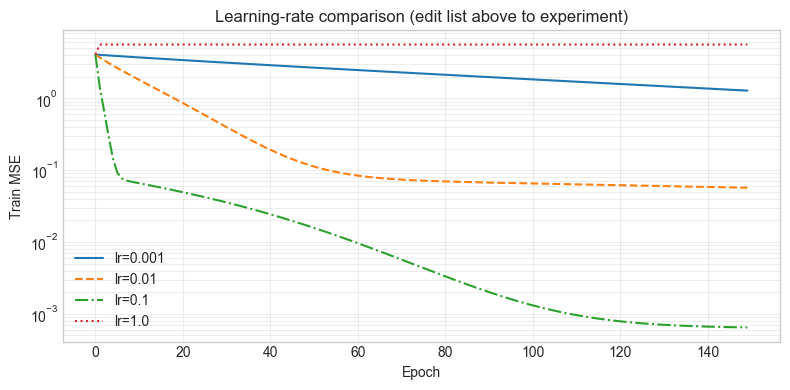

In [7]:
X, y = X_toy, y_toy

# TODO: edit this list and re-run (defaults chosen so Run All works)
learning_rates = [0.001, 0.01, 0.1, 1.0]

n_epochs = 150
seed = 42

plt.figure(figsize=(8, 4))
styles = ["-", "--", "-.", ":"]
for i, lr in enumerate(learning_rates):
    losses = train_sgd(X, y, learning_rate=lr, init_scale=0.5, n_epochs=n_epochs, seed=seed)
    ls = styles[i % len(styles)]
    plt.plot(np.maximum(losses, 1e-20), linestyle=ls, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.yscale("log")
plt.title("Learning-rate comparison (edit list above to experiment)")
plt.grid(True, which="both", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


<details>
<summary>Show one possible solution</summary>

```python
learning_rates = [0.001, 0.01, 0.1, 1.0]
```

Re-run the cell above. Very small `lr` → slow; moderate → smooth; `1.0` may oscillate or diverge.

</details>


---

## 5. First fix: momentum

**Idea:** Plain SGD can **oscillate** in narrow valleys. **Momentum** smooths updates with a velocity:

$$v \leftarrow \beta v + g, \qquad w \leftarrow w - \eta v$$

where $g$ is the gradient. Typical $\beta$ is `0.8`–`0.95`.

**Intuition:** updates blend current and past gradients — like a ball rolling downhill with inertia.


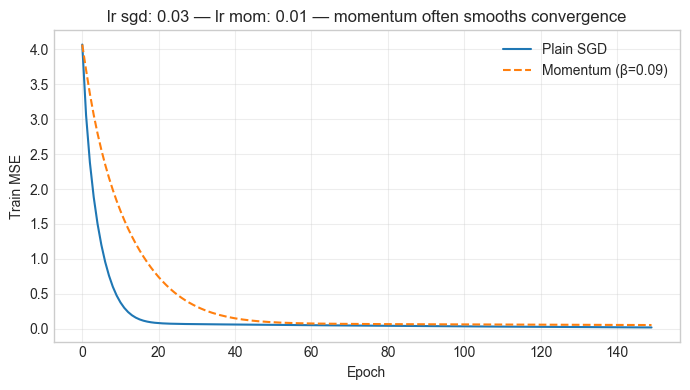

In [28]:
def train_momentum(X, y, learning_rate=0.1, beta=0.9, init_scale=0.5, n_epochs=120, seed=42):
    np.random.seed(seed)
    n_in, n_hid = X.shape[1], 4
    W1 = np.random.randn(n_in, n_hid) * init_scale
    b1 = np.zeros(n_hid)
    W2 = np.random.randn(n_hid, 1) * init_scale
    b2 = np.zeros(1)
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)
    losses = []
    for _ in range(n_epochs):
        y_pred, A1, Z1 = forward(X, W1, b1, W2, b2)
        losses.append(np.mean((y_pred - y) ** 2))
        dW1, db1, dW2, db2 = backward(X, A1, Z1, W2, y_pred, y)
        vW1 = beta * vW1 + dW1
        vb1 = beta * vb1 + db1
        vW2 = beta * vW2 + dW2
        vb2 = beta * vb2 + db2
        W1 -= learning_rate * vW1
        b1 -= learning_rate * vb1
        W2 -= learning_rate * vW2
        b2 -= learning_rate * vb2
    return losses

# sgd:
lr_sgd = 0.03
# momentum:
lr_mom = 0.01
beta_mom = 0.09

sgd = train_sgd(X_toy, y_toy, learning_rate=lr_sgd, n_epochs=150, seed=42)
mom = train_momentum(X_toy, y_toy, learning_rate=lr_mom, beta=beta_mom, n_epochs=150, seed=42)

plt.figure(figsize=(7, 4))
plt.plot(np.maximum(sgd, 1e-20), linestyle="-", label="Plain SGD")
plt.plot(np.maximum(mom, 1e-20), linestyle="--", label=f"Momentum (β={beta_mom})")
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
# plt.yscale("log")
plt.title(f"lr sgd: {lr_sgd} — lr mom: {lr_mom} — momentum often smooths convergence")
plt.grid(True, which="both", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


---

## 6. Train vs validation (intro to overfitting)

We generate **more data** and **hold out** a validation set. Each epoch we log train MSE and val MSE (forward on val only — **no** gradient step on val).

**Overfitting (intuition):** training loss keeps dropping but validation loss **rises** — the model memorizes training noise.


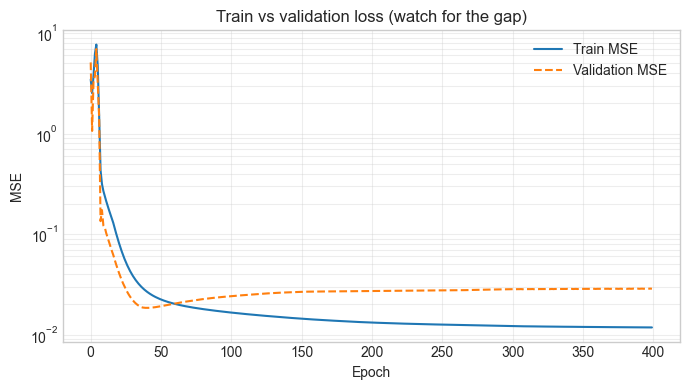

In [9]:
np.random.seed(7)
n_total = 48
X_all = np.random.randn(n_total, 2)
true_w = np.array([1.2, -0.7])
y_all = X_all @ true_w.reshape(2, 1) + 0.15 * np.random.randn(n_total, 1)

n_train = 36
X_train, X_val = X_all[:n_train], X_all[n_train:]
y_train, y_val = y_all[:n_train], y_all[n_train:]


def train_record_train_val(X_tr, y_tr, X_va, y_va, learning_rate=0.08, init_scale=0.8, n_epochs=400, seed=0):
    np.random.seed(seed)
    n_in, n_hid = X_tr.shape[1], 16
    W1 = np.random.randn(n_in, n_hid) * init_scale
    b1 = np.zeros(n_hid)
    W2 = np.random.randn(n_hid, 1) * init_scale
    b2 = np.zeros(1)
    train_losses, val_losses = [], []
    for _ in range(n_epochs):
        y_pred, A1, Z1 = forward(X_tr, W1, b1, W2, b2)
        train_losses.append(np.mean((y_pred - y_tr) ** 2))
        y_val_pred, _, _ = forward(X_va, W1, b1, W2, b2)
        val_losses.append(np.mean((y_val_pred - y_va) ** 2))
        dW1, db1, dW2, db2 = backward(X_tr, A1, Z1, W2, y_pred, y_tr)
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
    return train_losses, val_losses


tr_loss, va_loss = train_record_train_val(X_train, y_train, X_val, y_val, learning_rate=0.08, n_epochs=400, seed=0)

plt.figure(figsize=(7, 4))
plt.plot(np.maximum(tr_loss, 1e-20), linestyle="-", label="Train MSE")
plt.plot(np.maximum(va_loss, 1e-20), linestyle="--", label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.yscale("log")
plt.title("Train vs validation loss (watch for the gap)")
plt.grid(True, which="both", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


**How to read the plot**

- Both curves down and close → reasonable generalization on this split.
- Train improves while validation **rises** after an early minimum → **overfitting** signal.

**Pause:** Where is validation lowest? You might stop training there (early stopping — extension section).


---

## 7. Coding block 2 — exploration (≈40 min)

**Goal:** Combine **learning rate**, **momentum**, and optionally **init_scale**.

**Core path**

1. Set `lr_a` and `lr_b`.
2. With the **same** `seed`, run `train_sgd` and `train_momentum` for each.
3. Plot four curves and write one sentence: which reached lowest train MSE?

**Extension:** try `init_scale` in `{0.05, 0.5, 2.0}` at fixed `lr`.


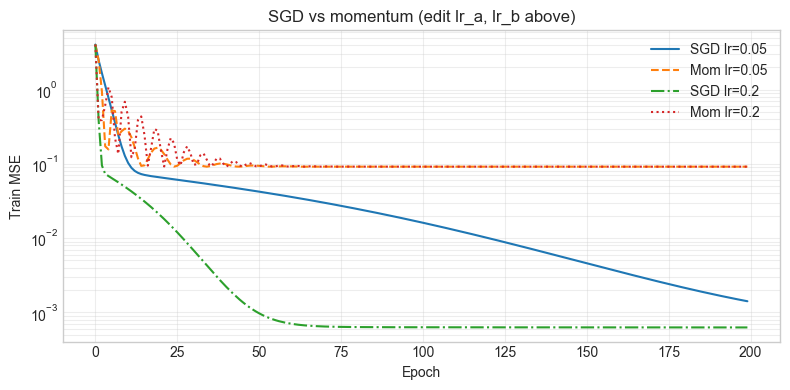

In [10]:
# TODO: try different pairs of learning rates
lr_a = 0.05
lr_b = 0.2
seed = 42
n_epochs = 200

curves = []
labels = []
for lr in (lr_a, lr_b):
    curves.append(train_sgd(X_toy, y_toy, learning_rate=lr, n_epochs=n_epochs, seed=seed))
    labels.append(f"SGD lr={lr}")
    curves.append(train_momentum(X_toy, y_toy, learning_rate=lr, beta=0.9, n_epochs=n_epochs, seed=seed))
    labels.append(f"Mom lr={lr}")

plt.figure(figsize=(8, 4))
linestyles = ["-", "--", "-.", ":"]
for i, (curve, lab) in enumerate(zip(curves, labels)):
    ls = linestyles[i % len(linestyles)]
    plt.plot(np.maximum(curve, 1e-20), linestyle=ls, label=lab)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.yscale("log")
plt.title("SGD vs momentum (edit lr_a, lr_b above)")
plt.grid(True, which="both", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


<details>
<summary>Show example completion</summary>

```python
lr_a, lr_b = 0.05, 0.2
```

Then re-run the cell above.

</details>


---

## Wrap-up: takeaways

1. **Learning rate** trades **speed** vs **stability** — read the **curve**, not only the final loss.
2. **Initialization** sets where optimization starts; bad scale → slow or unstable training.
3. **Momentum** smooths updates; often smoother loss curves at the same `lr`.
4. **Train vs validation** diagnoses **overfitting** when the gap widens.

**Habit:** change one thing → run → observe → explain.


---

## Homework / Post-class Extensions

*Optional.* Not required unless your instructor assigns them. Implement the TODO bodies and run small experiments.

| Idea | What to try |
|------|-------------|
| Early stopping | Stop when val loss does not improve for `patience` epochs |
| LR decay | Multiply `lr` by `< 1` each epoch |
| Adam | Optional later with PyTorch; here sketch only |
| Initialization grid | Scan `(init_scale, lr)` on `X_toy` |
| Cosine LR schedule | Cosine anneal from `lr_max` to `lr_min` |

Week 3’s notebook has **worked** examples of momentum, early stopping, decay, and cosine schedules — mirror that style if you want full solutions.


### Extension A — Early stopping (TODO scaffold)


In [11]:
def train_with_early_stopping(X_train, y_train, X_val, y_val, learning_rate=0.1, patience_epochs=10, max_epochs=500, seed=0):
    # TODO: init weights; each epoch: train loss + val loss; stop if val not improved for patience_epochs
    raise NotImplementedError


# train_losses, val_losses = train_with_early_stopping(...)
# plt.plot(train_losses); plt.plot(val_losses); plt.legend(["train", "val"])


### Extension B — Learning rate decay (TODO scaffold)


In [12]:
def train_lr_decay(X, y, lr0=0.1, decay=0.99, n_epochs=200, seed=42):
    # TODO: multiply learning rate by decay after each epoch
    raise NotImplementedError


### Extension C — Cosine learning rate (TODO scaffold)


In [13]:
def lr_cosine(t, T, lr_max, lr_min):
    # TODO: lr_t = lr_min + 0.5*(lr_max-lr_min)*(1+cos(pi*t/T))
    raise NotImplementedError


### Extension D — Initialization grid (TODO scaffold)


In [14]:
# TODO: nested loops over init_scale and lr; record final loss or mark diverged if loss > 1e3
pass
